Huffman Coding Visualizer

In [3]:
import heapq
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import networkx as nx
import pydot 


Node Class

In [4]:
class Node:
    def __init__(self, char=None, freq=0):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

Formatting func

In [ ]:
def print_header(title):
    print("\n")
    print(title)
    print("\n")

def print_subheader(title):
    print("\n")
    print(title)
    print("\n")

Building Huffman Tree

In [6]:
def build_huffman_tree(text):
    frequency = Counter(text)
    heap = []
    for character, freq in frequency.items():
        heap.append(Node(character, freq))
    heapq.heapify(heap)
    merge_steps = []
    # Edge Case
    # Only one unique character
    if len(heap) == 1:
        only_node = heapq.heappop(heap)
        root = Node(freq=only_node.freq)
        root.left = only_node
        return root, frequency, merge_steps

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        merged = Node(freq=left.freq + right.freq)

        merged.left = left
        merged.right = right

        merge_steps.append(
            (
                left.char if left.char else "#",
                left.freq,
                right.char if right.char else "#",
                right.freq,
                merged.freq
            )
        )

        heapq.heappush(heap, merged)
    return heap[0], frequency, merge_steps


Generate Huffman codes

In [7]:
def generate_codes(root, prefix="", codebook=None):
    if codebook is None:
        codebook = {}

    if root is None:
        return codebook

    # Leaf Node
    if root.char is not None:
        # Single Character Edge Case
        codebook[root.char] = prefix if prefix else "0"
        return codebook

    generate_codes(root.left, prefix + "0", codebook)
    generate_codes(root.right, prefix + "1", codebook)
    return codebook


Encode text

In [8]:
def huffman_encode(text, codebook):
    encoded = []
    for character in text:
        encoded.append(codebook[character])
    return "".join(encoded)


Decode text

In [9]:
def huffman_decode(encoded_text, root):
    # Edge Case
    # Only one unique character
    if root.left and root.right is None:
        return root.left.char * len(encoded_text)

    decoded = []
    current = root
    for bit in encoded_text:
        if bit == "0":
            current = current.left
        else:
            current = current.right
        if current.char is not None:
            decoded.append(current.char)
            current = root
    return "".join(decoded)

Character Frequency Table

In [ ]:
def display_frequency_table(frequency):
    print_header("CHARACTER FREQUENCY TABLE")

    print(f"{'Character':<20}{'Frequency'}")
    print("\n")

    for char, freq in sorted(frequency.items()):
        display_char = repr(char)[1:-1]
        if char == " ":
            display_char = "<space>"
        elif char == "\n":
            display_char = "<newline>"
        print(f"{display_char:<20}{freq}")


Initial Min Heap

In [ ]:
def display_initial_heap(frequency):
    print_header("INITIAL MIN HEAP")

    heap = []
    for char, freq in frequency.items():
        heapq.heappush(heap, (freq, char))

    print(f"{'Character':<20}{'Frequency'}")
    print("\n")

    while heap:
        freq, char = heapq.heappop(heap)
        display_char = repr(char)[1:-1]
        if char == " ":
            display_char = "<space>"
        elif char == "\n":
            display_char = "<newline>"
        print(f"{display_char:<20}{freq}")



Tree Construction steps

In [ ]:
def display_merge_steps(merge_steps):
    print_header("HUFFMAN TREE CONSTRUCTION")

    if not merge_steps:
        print("Only one unique character found.")
        print("No merge operations required.")
        return

    for step, data in enumerate(merge_steps, start=1):
        left_char, left_freq, right_char, right_freq, merged = data
        print(f"\nStep {step}")
        print(
            f"Merge "
            f"[{left_char}:{left_freq}]"
            f"  +  "
            f"[{right_char}:{right_freq}]"
        )
        print(f"New Internal Node Frequency = {merged}")
        print("\n")

Generated Codes

In [ ]:
def display_codebook(codebook):
    print_header("GENERATED HUFFMAN CODES")

    print(f"{'Character':<20}{'Code'}")
    print("\n")

    for char in sorted(codebook.keys()):
        display_char = repr(char)[1:-1]
        if char == " ":
            display_char = "<space>"
        elif char == "\n":
            display_char = "<newline>"
        print(f"{display_char:<20}{codebook[char]}")

Compression statistics 

In [14]:
def display_statistics(original_text, encoded_text):
    print_header("COMPRESSION STATISTICS")

    original_bits = len(original_text) * 8
    compressed_bits = len(encoded_text)

    saved_bits = original_bits - compressed_bits
    ratio = (compressed_bits / original_bits) * 100

    print(f"Original Characters      : {len(original_text)}")
    print(f"Original Size            : {original_bits} bits")
    print()
    print(f"Compressed Size          : {compressed_bits} bits")
    print(f"Bits Saved               : {saved_bits} bits")
    print(f"Compression Ratio        : {ratio:.2f}%")
    print(f"Space Saved              : {100-ratio:.2f}%")

Verify Decode text

In [15]:
def verify_decoding(original, decoded):
    print_header("VERIFICATION")

    if original == decoded:
        print("Original Text :")
        print(original)
        print("\nDecoded Text :")
        print(decoded)
        print("\nHuffman Encoding and Decoding Successful")

    else:

        print("Verification Failed")

Save output files

In [16]:
def save_outputs(encoded_text, codebook):
    
    output_dir = Path.cwd() / "outputs"
    output_dir.mkdir(exist_ok=True)

    compressed_path = output_dir / "compressed.txt"
    codebook_path = output_dir / "codes.json"

    with open(compressed_path, "w", encoding="utf-8") as file:
        file.write(encoded_text)

    with open(codebook_path, "w", encoding="utf-8") as file:
        json.dump(codebook, file, indent=4)

    print_header("FILES SAVED")
    print(f"Compressed File : {compressed_path}")
    print(f"Codebook File   : {codebook_path}")

Time Complexity Analysis

In [17]:
def display_complexity():

    print_header("TIME COMPLEXITY ANALYSIS")

    print("Frequency Counting   : O(n)")
    print("Build Min Heap       : O(k)")
    print("Build Huffman Tree   : O(k log k)")
    print("Generate Codes       : O(k)")
    print("Encoding             : O(n)")
    print("Decoding             : O(b)")
    print()
    print("n = Number of characters in the input text")
    print("k = Number of unique characters")
    print("b = Number of bits in the encoded text")

Huffman Visualizer 

In [18]:
def visualize_tree(root):

    print_header("HUFFMAN TREE VISUALIZATION")
    # Create output folder
    output_dir = Path.cwd() / "outputs"
    output_dir.mkdir(exist_ok=True)

    image_path = output_dir / "huffman_tree.png"
    graph = nx.DiGraph()
    def add_nodes(node):

        if node is None:
            return

        node_id = str(id(node))
        # Leaf Node
        if node.char is not None:

            label = f"{node.char}\n({node.freq})"
            color = "lightgreen"

        # Internal Node
        else:

            label = f"{node.freq}"
            color = "lightblue"
        graph.add_node(
            node_id,
            label=label,
            style="filled",
            fillcolor=color,
            shape="circle"
        )
        # Left Child
        if node.left:

            left_id = str(id(node.left))

            graph.add_edge(
                node_id,
                left_id,
                label="0"
            )

            add_nodes(node.left)
        # Right Child
        if node.right:
            right_id = str(id(node.right))
            graph.add_edge(
                node_id,
                right_id,
                label="1"
            )
            add_nodes(node.right)

    add_nodes(root)
    dot_graph = nx.nx_pydot.to_pydot(graph)

    dot_graph.set_rankdir("TB")
    dot_graph.set_nodesep("0.4")
    dot_graph.set_ranksep("0.6")

    for node in dot_graph.get_nodes():
        node.set_fontname("Arial")
        node.set_fontsize("12")
        node.set_penwidth("1.5")
    
    for edge in dot_graph.get_edges():
        edge.set_fontsize("11")
        edge.set_fontname("Arial")
        edge.set_color("black")
    
    dot_graph.write_png(str(image_path))
    print(f"Tree saved to:\n{image_path}")

    img = mpimg.imread(image_path)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        "Huffman Tree",
        fontsize=18,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

HUFFMAN CODING VISUALIZER

                 CHARACTER FREQUENCY TABLE                  
Character           Frequency
-----------------------------------
A                   3
B                   1
N                   2

                      INITIAL MIN HEAP                      
Character           Frequency
-----------------------------------
B                   1
N                   2
A                   3

                 HUFFMAN TREE CONSTRUCTION                  

Step 1
Merge [B:1]  +  [N:2]
New Internal Node Frequency = 3
----------------------------------------

Step 2
Merge [A:3]  +  [#:3]
New Internal Node Frequency = 6
----------------------------------------

                  GENERATED HUFFMAN CODES                   
Character           Code
----------------------------------------
A                   0
B                   10
N                   11

                   ENCODED BINARY STRING                    
100110110

                        DECODED TEXT             

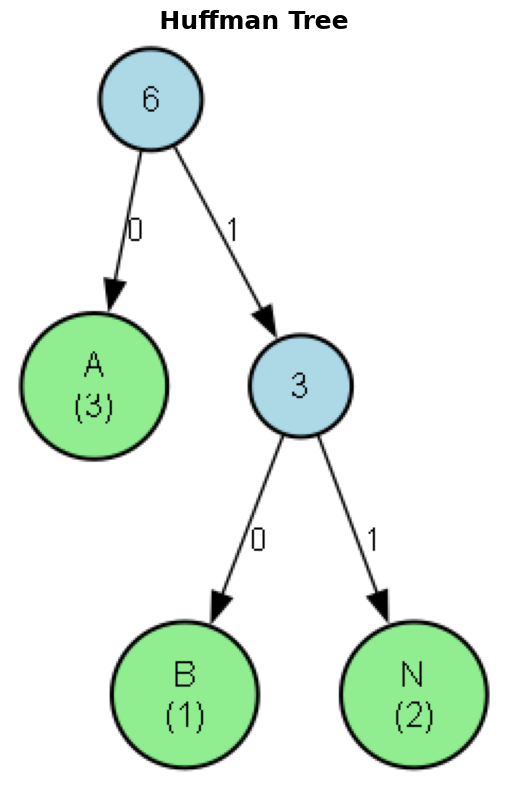


                  TIME COMPLEXITY ANALYSIS                  
Frequency Counting   : O(n)
Build Min Heap       : O(k)
Build Huffman Tree   : O(k log k)
Generate Codes       : O(k)
Encoding             : O(n)
Decoding             : O(b)

n = Number of characters in the input text
k = Number of unique characters
b = Number of bits in the encoded text
Project Completed Successfully!


In [20]:
def main():

    print("HUFFMAN CODING VISUALIZER")
    
    text = input("\nEnter the text to compress:\n")

    # Handle empty input
    if not text.strip():
        print("\nError: Input cannot be empty.")
        return

    root, frequency, merge_steps = build_huffman_tree(text)
    display_frequency_table(frequency)
    display_initial_heap(frequency)
    display_merge_steps(merge_steps)

    codebook = generate_codes(root)
    display_codebook(codebook)

    encoded_text = huffman_encode(text, codebook)
    decoded_text = huffman_decode(encoded_text, root)

    print_header("ENCODED BINARY STRING")
    print(encoded_text)

    print_header("DECODED TEXT")
    print(decoded_text)

    display_statistics(text, encoded_text)
    verify_decoding(text, decoded_text)
    save_outputs(encoded_text, codebook)
    visualize_tree(root)
    display_complexity()

    print("Project Completed Successfully!")

if __name__ == "__main__":
    main()